<a href="https://colab.research.google.com/github/reyhan1997/Transaction-data-exploration/blob/main/transactions_explore_version_July_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
url = 'https://raw.githubusercontent.com/reyhan1997/Transaction-data-exploration/refs/heads/main/Transactions.csv'
import numpy as np
import pandas as pd
df = pd.read_csv(url)

In [ ]:
df.shape

(62884, 31)

In [ ]:
#Identify type of input for each column and count the total input non-null (not empty cell)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   TransactionID         62884 non-null  int64 
 1   OrderNumber           62884 non-null  int64 
 2   LineItem              62884 non-null  int64 
 3   OrderDate             62884 non-null  object
 4   DeliveryDate          13165 non-null  object
 5   Quantity              62884 non-null  int64 
 6   CustomerID            62884 non-null  int64 
 7   CustomerGender        62884 non-null  object
 8   CustomerName          62884 non-null  object
 9   CustomerCity          62884 non-null  object
 10  CustomerStateCode     62854 non-null  object
 11  CustomerState         62884 non-null  object
 12  CustomerZip           62884 non-null  object
 13  CustomerCountry       62884 non-null  object
 14  CustomerContinent     62884 non-null  object
 15  CustomerDOB           62884 non-null

In [ ]:
#Show only 5 rows value for each column
df.head()

,TransactionID,OrderNumber,LineItem,OrderDate,DeliveryDate,Quantity,CustomerID,CustomerGender,CustomerName,CustomerCity,...,ProductID,ProductName,ProductBrand,ProductColor,ProductCost,ProductPrice,ProductSubcategoryID,ProductSubcategory,ProductCategoryID,ProductCategory
0,3660001,366000,1,1/1/2016,NaN,1,265598,Male,Tyler Vaught,London,...,1304,Contoso Lens Adapter M450 White,Contoso,White,$31.27,$68.00,406,Cameras & Camcorders Accessories,4,Cameras and camcorders
1,3660011,366001,1,1/1/2016,1/13/2016,2,1269051,Male,Frank Upchurch,Auberry,...,1048,A. Datum SLR Camera X136 Silver,A. Datum,Silver,$141.47,$427.00,402,Digital SLR Cameras,4,Cameras and camcorders
2,3660012,366001,2,1/1/2016,1/13/2016,1,1269051,Male,Frank Upchurch,Auberry,...,2007,Fabrikam Microwave 1.5CuFt X1100 Black,Fabrikam,Black,$220.64,$665.94,803,Microwaves,8,Home Appliances
3,3660021,366002,1,1/1/2016,1/12/2016,7,266019,Female,Joan Roche,Red Deer,...,1106,Contoso SLR Camera M146 Orange,Contoso,Orange,$148.08,$322.00,402,Digital SLR Cameras,4,Cameras and camcorders
4,3660022,366002,2,1/1/2016,1/12/2016,1,266019,Female,Joan Roche,Red Deer,...,373,Adventure Works Laptop8.9 E0890 White,Adventure Works,White,$166.20,$326.00,301,Laptops,3,Computers


In [ ]:
#Checklist column name
df.columns.tolist()

['TransactionID',
 'OrderNumber',
 'LineItem',
 'OrderDate',
 'DeliveryDate',
 'Quantity',
 'CustomerID',
 'CustomerGender',
 'CustomerName',
 'CustomerCity',
 'CustomerStateCode',
 'CustomerState',
 'CustomerZip',
 'CustomerCountry',
 'CustomerContinent',
 'CustomerDOB',
 'StoreID',
 'StoreCountry',
 'StoreState',
 'StoreSqMeters',
 'StoreOpenDate',
 'ProductID',
 'ProductName',
 'ProductBrand',
 'ProductColor',
 'ProductCost',
 'ProductPrice',
 'ProductSubcategoryID',
 'ProductSubcategory',
 'ProductCategoryID',
 'ProductCategory']

In [ ]:
df["OrderDate"]

,OrderDate
0,1/1/2016
1,1/1/2016
2,1/1/2016
3,1/1/2016
4,1/1/2016
...,...
62879,2/20/2021
62880,2/20/2021
62881,2/20/2021
62882,2/20/2021


In [ ]:
df.isnull().sum()

,0
TransactionID,0
OrderNumber,0
LineItem,0
OrderDate,0
DeliveryDate,49719
Quantity,0
CustomerID,0
CustomerGender,0
CustomerName,0
CustomerCity,0


In [ ]:
df['CustomerGender'].value_counts("Female")

,proportion
CustomerGender,
Male,0.505757
Female,0.494243


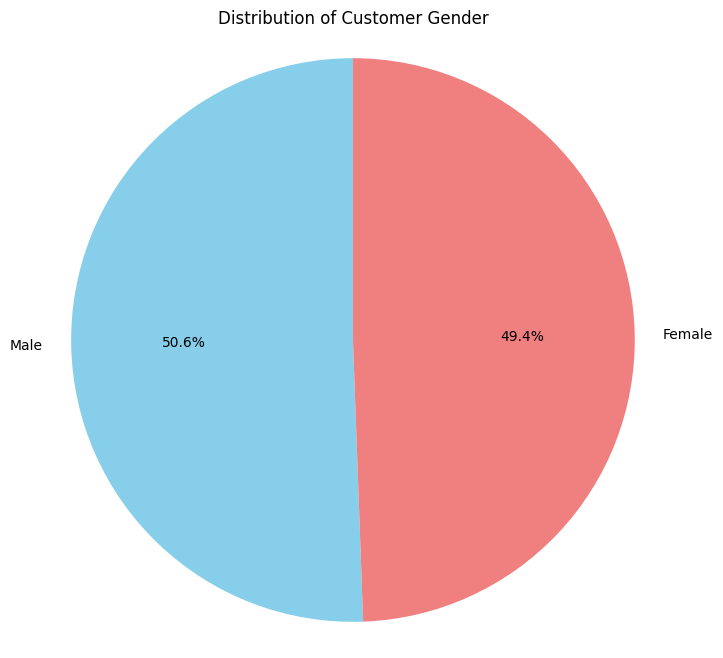

In [ ]:
import matplotlib.pyplot as plt

gender_counts = df['CustomerGender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Customer Gender')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
df['ProductPrice'] = df['ProductPrice'].astype(str).str.replace('$', '', regex=False)
df['ProductPrice'] = pd.to_numeric(df['ProductPrice'], errors='coerce')

# Display the data types to confirm the change
display(df['ProductPrice'].dtype)

dtype('float64')

In [ ]:
# Check for any missing values introduced by the conversion
display(df['ProductPrice'].isnull().sum())

np.int64(2185)

In [ ]:
df['ProductCategory'].unique()

array(['Cameras and camcorders', 'Home Appliances', 'Computers',
       'TV and Video', 'Cell phones', 'Music, Movies and Audio Books',
       'Games and Toys', 'Audio'], dtype=object)

In [ ]:
df['CustomerContinent'].unique()

array(['North America', 'Europe', 'Australia'], dtype=object)

In [ ]:
df['StoreCountry'].unique().tolist()

['Canada',
 'Online',
 'United Kingdom',
 'Netherlands',
 'United States',
 'Italy',
 'France',
 'Germany',
 'Australia']

In [ ]:
df['ProductColor'].unique()

array(['White', 'Silver', 'Black', 'Orange', 'Blue', 'Gold', 'Brown',
       'Red', 'Green', 'Purple', 'Grey', 'Yellow', 'Azure', 'Pink',
       'Silver Grey', 'Transparent'], dtype=object)

In [ ]:
df['StoreOpenDate'].unique()

array(['4/4/2015', '1/1/2010', '12/9/2015', '1/1/2015', '1/1/2008',
       '3/4/2005', '1/1/2014', '1/1/2012', '6/7/2013', '3/6/2008',
       '6/6/2012', '8/8/2012', '6/3/2010', '12/15/2012', '1/7/2012',
       '12/15/2009', '1/12/2008', '7/2/2014', '8/8/2008', '7/8/2007',
       '6/3/2009', '6/3/2018', '3/5/2019'], dtype=object)

In [ ]:
# Display rows where 'ProductPrice' is NaN to understand the original values
display(df[df['ProductPrice'].isnull()][['ProductPrice', 'ProductCost']].head())

,ProductPrice,ProductCost
6,NaN,$527.53
27,NaN,$331.32
41,NaN,"$1,060.22"
51,NaN,$960.82
67,NaN,"$1,060.22"


Identify location of Store with highest Revenue from beginning

In [ ]:
display(df['StoreID']['StoreOpenDate'])

KeyError: 'StoreOpenDate'

In [ ]:
df['StoreOpenDate'] = pd.to_datetime(df['StoreOpenDate'])
store_open_dates = df[['StoreID', 'StoreOpenDate']].drop_duplicates().sort_values(by='StoreID')
display(store_open_dates)

,StoreID,StoreOpenDate
1,0,2010-01-01
2371,1,2008-01-01
75,2,2008-01-12
130,4,2010-01-01
262,5,2015-12-09
137,6,2010-01-01
101,8,2014-07-02
14,9,2005-03-04
0,10,2015-04-04
255,12,2012-06-06


In [ ]:
store_country_map = df[['StoreID', 'StoreCountry']].drop_duplicates()
store_open_dates_with_country = pd.merge(store_open_dates, store_country_map, on='StoreID', how='left')
display(store_open_dates_with_country.sort_values(by=['StoreCountry', 'StoreID']))

,StoreID,StoreOpenDate,StoreCountry
1,1,2008-01-01,Australia
2,2,2008-01-12,Australia
3,4,2010-01-01,Australia
4,5,2015-12-09,Australia
5,6,2010-01-01,Australia
6,8,2014-07-02,Canada
7,9,2005-03-04,Canada
8,10,2015-04-04,Canada
9,12,2012-06-06,France
10,13,2013-06-07,France


In [ ]:
all_store_ids = set(df['StoreID'].unique())
combined_store_ids = set(store_open_dates_with_country['StoreID'].unique())

missing_store_ids = sorted(list(all_store_ids - combined_store_ids))

if missing_store_ids:
    print(f"The following StoreIDs are present in the original DataFrame but missing from the combined table: {missing_store_ids}")
else:
    print("All StoreIDs from the original DataFrame are present in the combined table.")

All StoreIDs from the original DataFrame are present in the combined table.


In [ ]:
Store_ID = df['StoreID'].unique()
print(np.sort(Store_ID))
#Identify empty input in table StoreID
df['StoreID'].isnull().sum()

[ 0  1  2  4  5  6  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 26 27
 28 29 30 31 32 33 34 36 37 38 39 40 41 42 43 44 45 47 48 49 50 51 53 54
 55 56 57 59 61 62 63 64 65 66]


np.int64(0)

In [ ]:
df['ProductBrand'].unique()

array(['Contoso', 'A. Datum', 'Fabrikam', 'Adventure Works',
       'The Phone Company', 'Proseware', 'Wide World Importers',
       'Tailspin Toys', 'Southridge Video', 'Litware',
       'Northwind Traders'], dtype=object)

In [ ]:
#Confirm the missing input in 'DeliveryDate' column
missing_delivery_dates = df['DeliveryDate'].isnull().sum()
total_rows = len(df)
#Identify proportion of missing input in 'DeliveryDate' column
percentage_missing = (missing_delivery_dates / total_rows) * 100
print(f"Number of missing 'DeliveryDate' values: {missing_delivery_dates}")
print(f"Total rows in DataFrame: {total_rows}")
print(f"Percentage of missing 'DeliveryDate' values: {percentage_missing:.2f}%")

Number of missing 'DeliveryDate' values: 49719
Total rows in DataFrame: 62884
Percentage of missing 'DeliveryDate' values: 79.06%


In [ ]:
df['ProductCost'] = df['ProductCost'].astype(str).str.replace('$', '', regex=False)
df['ProductCost'] = pd.to_numeric(df['ProductCost'], errors='coerce')

# Display the data types to confirm the change
display(df['ProductCost'].dtype)

dtype('float64')

In [ ]:
# Check for any missing values introduced by the conversion
display(df['ProductCost'].isnull().sum())

np.int64(117)

In [ ]:
# Display rows where 'ProductPrice' is NaN to understand the original values
display(df['ProductCost'].head())

,ProductCost
0,31.27
1,141.47
2,220.64
3,148.08
4,166.20


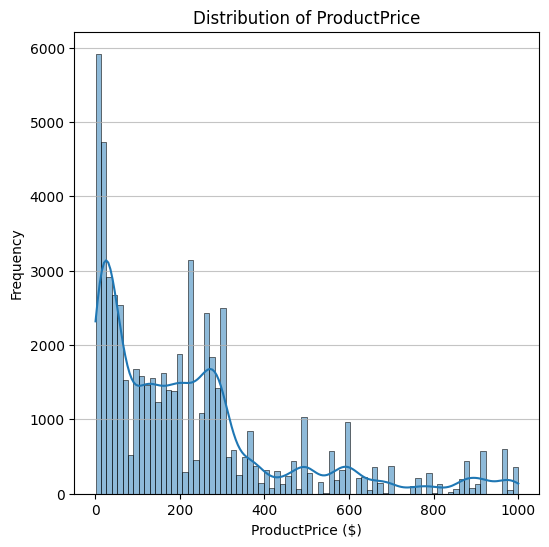

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.histplot(df['ProductPrice'].dropna(), kde=True)
plt.title('Distribution of ProductPrice')
plt.xlabel('ProductPrice ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
df['ProductCategory'].value_counts()

,count
ProductCategory,
Computers,14025
Cell phones,10158
"Music, Movies and Audio Books",9169
Audio,7489
Games and Toys,7061
Home Appliances,5865
Cameras and camcorders,5559
TV and Video,3558


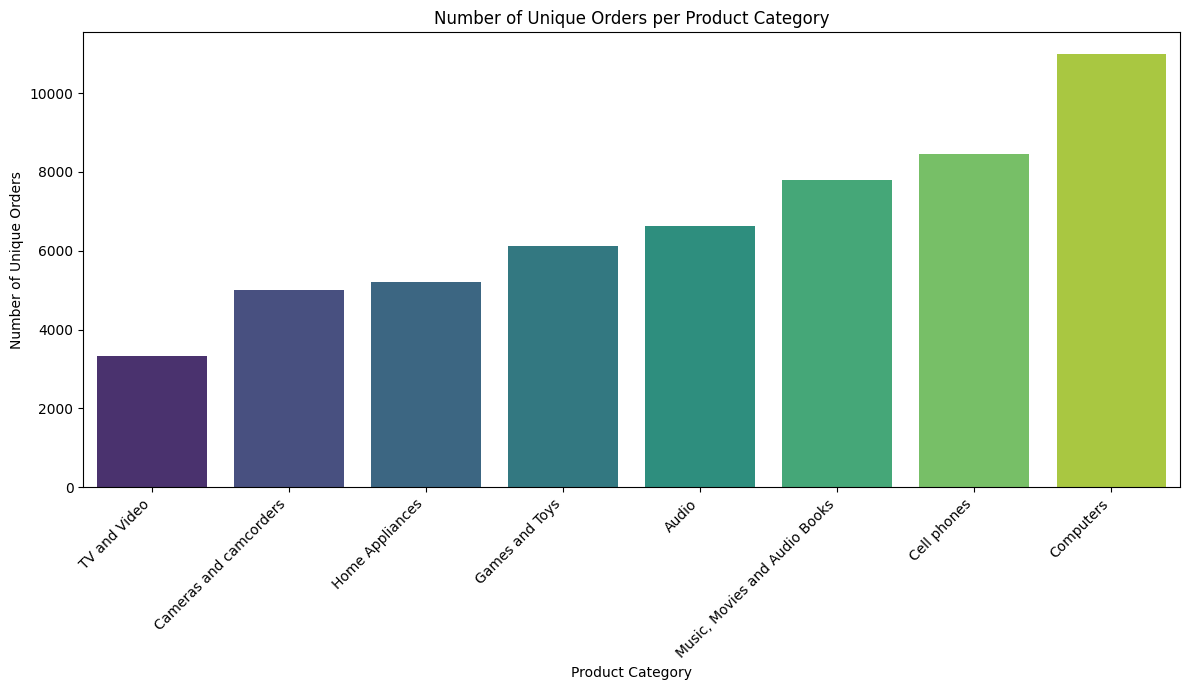

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of unique orders per ProductCategory
orders_per_category = df.groupby('ProductCategory')['OrderNumber'].nunique().sort_values(ascending=True)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=orders_per_category.index, y=orders_per_category.values, hue=orders_per_category.index, palette='viridis', legend=False)
plt.title('Number of Unique Orders per Product Category')
plt.xlabel('Product Category')
plt.ylabel('Number of Unique Orders')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
top_customers_by_orders = df.groupby(['CustomerID', 'CustomerName'])['OrderNumber'].nunique().sort_values(ascending=False)
top_customers_by_orders.head(25)

,,OrderNumber
CustomerID,CustomerName,
723572,Gaspare Trevisan,14
2080484,Delmer Martinez,12
1349131,Katherine Rosales,11
574327,Jens Himmel,10
2014226,Theodor Kristoffersen,10
1286602,Frances Colbert,10
1388023,David Breton,10
930705,Elizabeth Butler,10
1098687,Edward Rose,10


In [ ]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
min_order_date = df['OrderDate'].min()
max_order_date = df['OrderDate'].max()
print(f"OrderDate Min: {min_order_date}")
print(f"OrderDate Max: {max_order_date}")
print(f"OrderDate Range: {max_order_date - min_order_date}")

OrderDate Min: 2016-01-01 00:00:00
OrderDate Max: 2021-02-20 00:00:00
OrderDate Range: 1877 days 00:00:00


In [ ]:
df['Revenue'] = df['Quantity'] * df['ProductPrice']
display(df.head())

,TransactionID,OrderNumber,LineItem,OrderDate,DeliveryDate,Quantity,CustomerID,CustomerGender,CustomerName,CustomerCity,...,ProductName,ProductBrand,ProductColor,ProductCost,ProductPrice,ProductSubcategoryID,ProductSubcategory,ProductCategoryID,ProductCategory,Revenue
0,3660001,366000,1,2016-01-01,NaN,1,265598,Male,Tyler Vaught,London,...,Contoso Lens Adapter M450 White,Contoso,White,31.27,68.00,406,Cameras & Camcorders Accessories,4,Cameras and camcorders,68.00
1,3660011,366001,1,2016-01-01,1/13/2016,2,1269051,Male,Frank Upchurch,Auberry,...,A. Datum SLR Camera X136 Silver,A. Datum,Silver,141.47,427.00,402,Digital SLR Cameras,4,Cameras and camcorders,854.00
2,3660012,366001,2,2016-01-01,1/13/2016,1,1269051,Male,Frank Upchurch,Auberry,...,Fabrikam Microwave 1.5CuFt X1100 Black,Fabrikam,Black,220.64,665.94,803,Microwaves,8,Home Appliances,665.94
3,3660021,366002,1,2016-01-01,1/12/2016,7,266019,Female,Joan Roche,Red Deer,...,Contoso SLR Camera M146 Orange,Contoso,Orange,148.08,322.00,402,Digital SLR Cameras,4,Cameras and camcorders,2254.00
4,3660022,366002,2,2016-01-01,1/12/2016,1,266019,Female,Joan Roche,Red Deer,...,Adventure Works Laptop8.9 E0890 White,Adventure Works,White,166.20,326.00,301,Laptops,3,Computers,326.00


In [ ]:
revenue_by_country = df.groupby('StoreCountry')['Revenue'].sum().sort_values(ascending=False)
percentage_revenue_by_country = (revenue_by_country / revenue_by_country.sum()) * 100

print("Total Revenue by Store Country:")
display(revenue_by_country)

print("\nPercentage Revenue by Store Country:")
display(percentage_revenue_by_country)

Total Revenue by Store Country:


,Revenue
StoreCountry,
United States,18353871.59
Online,8939293.31
United Kingdom,4553431.65
Germany,3167783.86
Canada,2857289.69
Italy,1560623.38
Australia,1492524.51
Netherlands,1283293.19
France,994824.99



Percentage Revenue by Store Country:


,Revenue
StoreCountry,
United States,42.482926
Online,20.691402
United Kingdom,10.539635
Germany,7.332335
Canada,6.613647
Italy,3.612309
Australia,3.454683
Netherlands,2.970384
France,2.302679


/tmp/ipykernel_522/3944475717.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_country.index, y=revenue_by_country.values, palette='viridis')


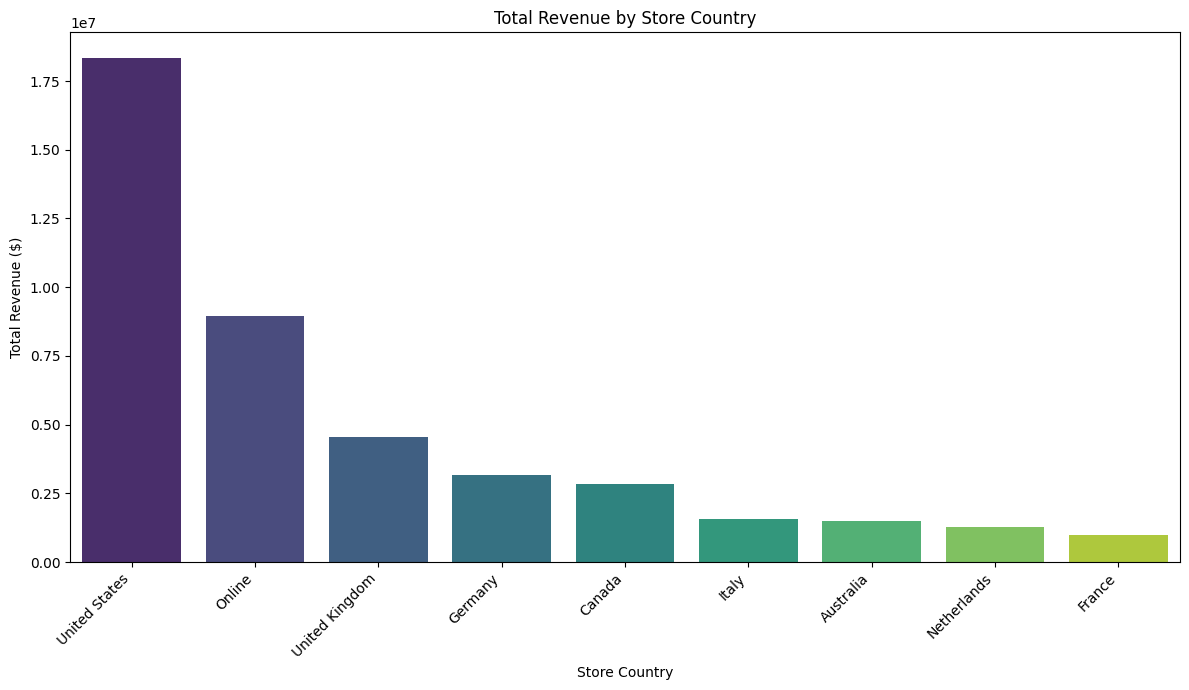

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart for Total Revenue by Store Country
plt.figure(figsize=(12, 7))
sns.barplot(x=revenue_by_country.index, y=revenue_by_country.values, palette='viridis')
plt.title('Total Revenue by Store Country')
plt.xlabel('Store Country')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

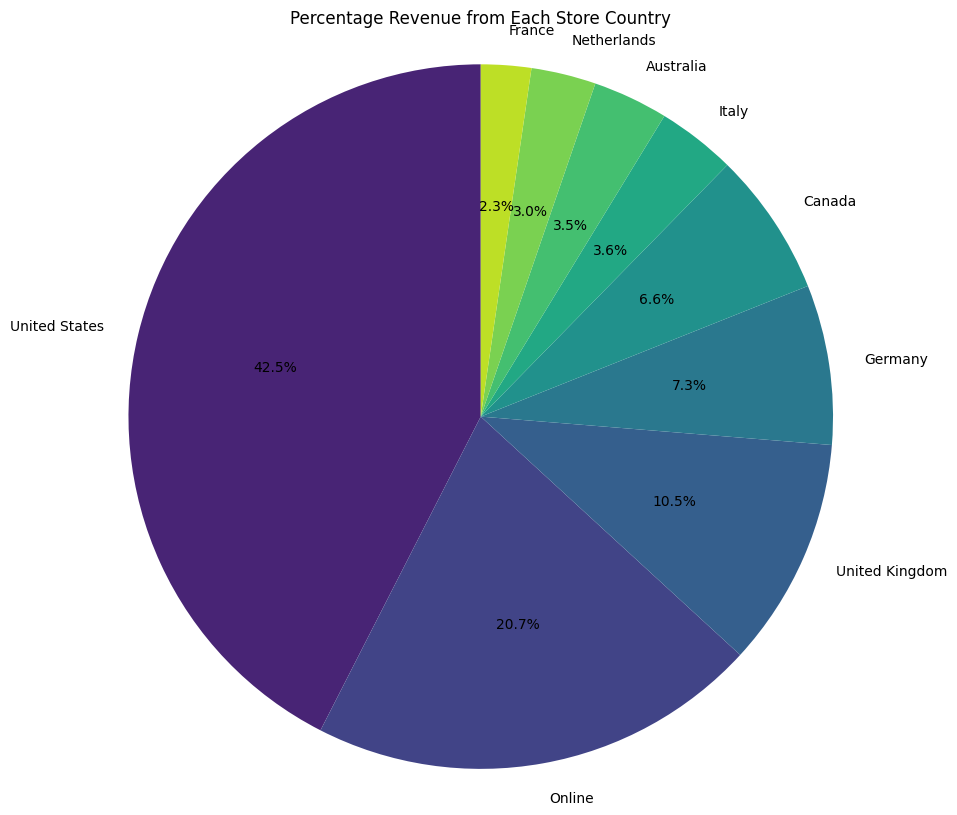

In [ ]:
fig = plt.figure(figsize=(10, 10))
plt.pie(percentage_revenue_by_country, labels=percentage_revenue_by_country.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(percentage_revenue_by_country)))
plt.title('Percentage Revenue from Each Store Country')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

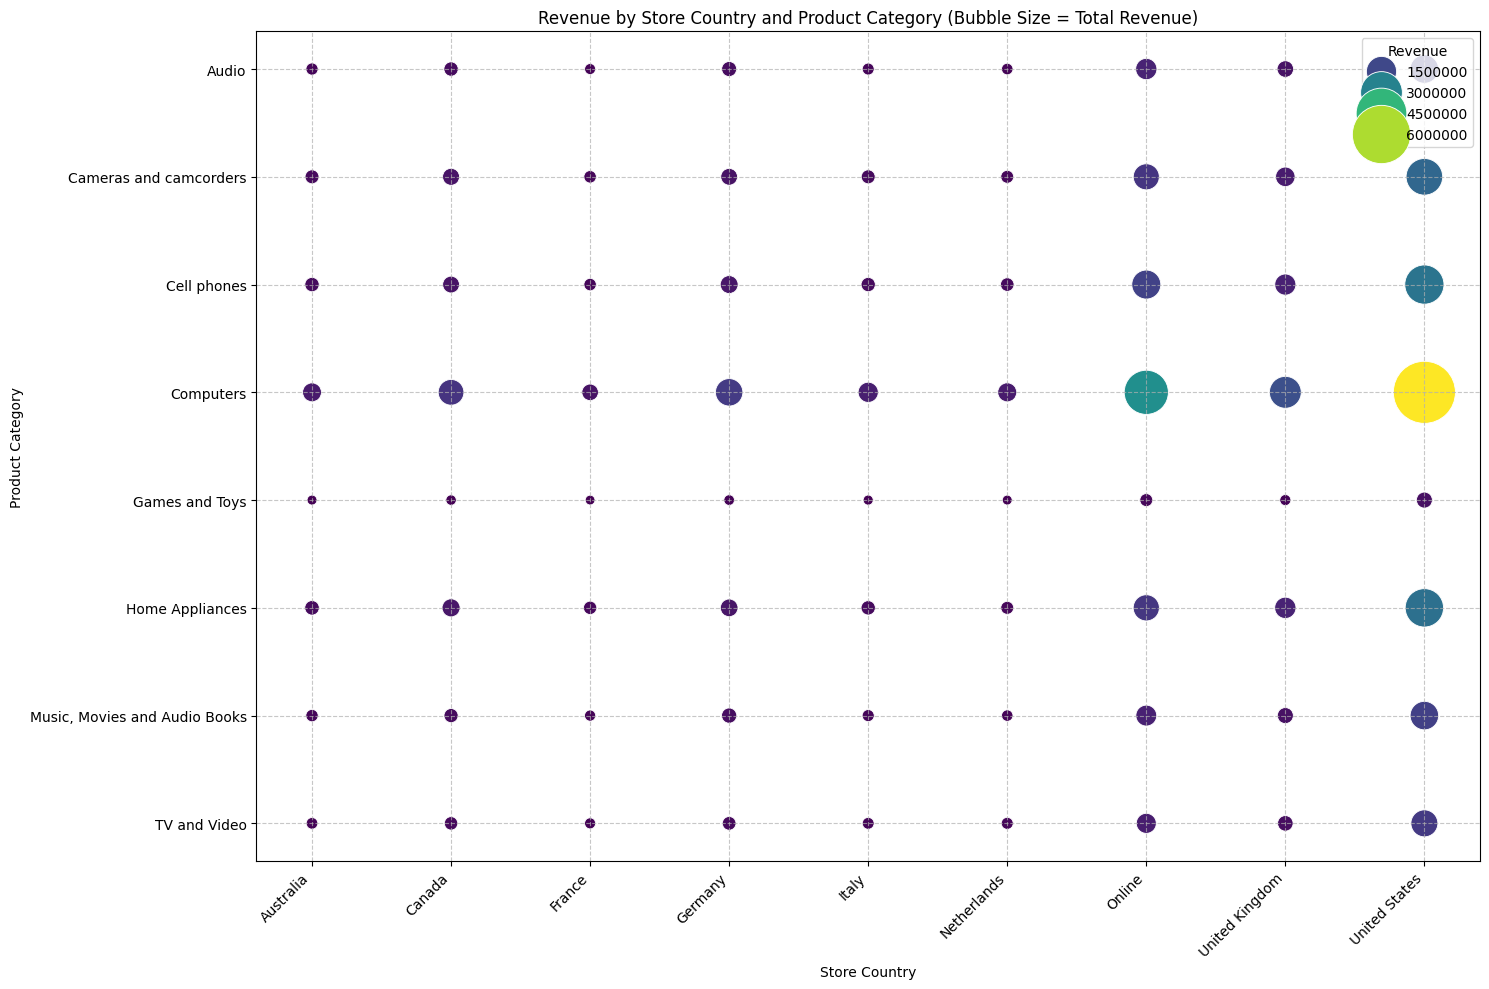

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate revenue by StoreCountry and ProductCategory
revenue_product_country = df.groupby(['StoreCountry', 'ProductCategory'])['Revenue'].sum().reset_index()

# Create the bubble plot
plt.figure(figsize=(15, 10))
sns.scatterplot(
    data=revenue_product_country,
    x='StoreCountry',
    y='ProductCategory',
    size='Revenue', # Map revenue to bubble size
    sizes=(50, 2000), # Define the range of bubble sizes
    hue='Revenue', # Map revenue to color for better distinction
    palette='viridis', # Color palette for the bubbles
    legend='brief' # Show a concise legend for size and color
)

plt.title('Revenue by Store Country and Product Category (Bubble Size = Total Revenue)')
plt.xlabel('Store Country')
plt.ylabel('Product Category')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for better context
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()